# Research Methodology and Evidence

This notebook establishes how research claims in AXIS CMS should be read.

It is not a generic introduction to experimentation or data analysis. The goal is narrower: to make the AXIS-specific relationship between mechanisms, traces, metrics, and comparisons explicit enough that later notebooks can make strong claims without quietly shifting standards of evidence.

This notebook uses the `system_aw-baseline` workspace as its running example, specifically the `world-variations` series. That subseries gives us three things we need for methodological framing:

- a baseline anchor run
- paired comparisons against controlled world changes
- persisted episode traces with system-specific decision data


In [13]:
from _bootstrap import setup_notebook

ROOT = setup_notebook()


## Notebook Role

This is primarily an **analyze + explain** notebook.

The question is not "what is the best-performing configuration?" The question is:

> What kinds of evidence are available in AXIS CMS, and what kinds of claims does each artifact type actually justify?

The practical risk we want to avoid is familiar: reading too much into a single pretty trace, or too much into a single aggregate metric table.


In [14]:
from pathlib import Path

import pandas as pd
from IPython.display import display

from research.lib import load_json, load_series_summary
from research.lib.plotting import bar_plot, line_plot, lines_plot

WORKSPACE = ROOT / 'workspaces' / 'system_aw-baseline'
SERIES_DIR = WORKSPACE / 'series' / 'world-variations'
SERIES_SUMMARY_PATH = SERIES_DIR / 'measurements' / 'series-summary.json'

series_summary = load_series_summary(SERIES_SUMMARY_PATH)
experiments = {experiment['label']: experiment for experiment in series_summary['experiments']}

baseline_experiment = experiments['world-baseline-anchor']
scarcity_experiment = experiments['world-sparse-scarcity']


def run_dir(experiment: dict) -> Path:
    return SERIES_DIR / 'results' / experiment['candidate_experiment_id'] / 'runs' / 'run-0000'


def comparison_path(experiment: dict) -> Path:
    return WORKSPACE / experiment['comparison_output_path']


baseline_run_dir = run_dir(baseline_experiment)
scarcity_run_dir = run_dir(scarcity_experiment)

baseline_run_summary = load_json(baseline_run_dir / 'run_summary.json')
baseline_behavior_metrics = load_json(baseline_run_dir / 'behavior_metrics.json')
scarcity_run_summary = load_json(scarcity_run_dir / 'run_summary.json')
scarcity_behavior_metrics = load_json(scarcity_run_dir / 'behavior_metrics.json')
scarcity_comparison = load_json(comparison_path(scarcity_experiment))

baseline_episode_path = baseline_run_dir / 'episodes' / 'episode_0001.json'
baseline_episode = load_json(baseline_episode_path)

print('Workspace:', WORKSPACE)
print('Series:', series_summary['series_title'])
print('Baseline experiment:', baseline_experiment['title'])
print('Comparison example:', scarcity_experiment['title'])
print('Trace example:', baseline_episode_path.relative_to(ROOT))


Workspace: /workspaces/axis-system-cms/workspaces/system_aw-baseline
Series: System A+W World Variations on Sensory-Novelty Fixed Agent
Baseline experiment: Baseline World Anchor
Comparison example: Sparse Scarcity Patches
Trace example: workspaces/system_aw-baseline/series/world-variations/results/e364d733f3234359a4a1b40bed448772/runs/run-0000/episodes/episode_0001.json


## Evidence Classes in AXIS CMS

AXIS exposes several evidence layers, and they are not interchangeable.

A useful working rule for the research notebooks is:

> the stronger the claim, the more we should combine artifact types instead of overloading one of them.

In practice, the evidence ladder looks like this:


In [15]:
evidence_rows = [
    {
        'evidence_type': 'Toy mechanism example',
        'best_for': 'Clarifying one formula, scoring rule, or architectural constraint',
        'weak_for': 'Showing prevalence in real runs',
        'typical_axis_artifact': 'In-notebook synthetic construction',
    },
    {
        'evidence_type': 'Single episode trace',
        'best_for': 'Showing how local decisions emerged step by step',
        'weak_for': 'Generalizing to typical behavior',
        'typical_axis_artifact': 'episodes/episode_XXXX.json',
    },
    {
        'evidence_type': 'Run summary / behavior metrics',
        'best_for': 'Summarizing aggregate tendencies across many episodes',
        'weak_for': 'Explaining why one trajectory happened',
        'typical_axis_artifact': 'run_summary.json / behavior_metrics.json',
    },
    {
        'evidence_type': 'Paired comparison',
        'best_for': 'Localizing what changed under a controlled intervention',
        'weak_for': 'Explaining internal mechanism by itself',
        'typical_axis_artifact': 'comparisons/comparison-XXX.json',
    },
    {
        'evidence_type': 'Series summary',
        'best_for': 'Placing one result in a broader experimental context',
        'weak_for': 'Proving a mechanism at the step level',
        'typical_axis_artifact': 'series-summary.json',
    },
]

evidence_df = pd.DataFrame(evidence_rows)
display(evidence_df)


,evidence_type,best_for,weak_for,typical_axis_artifact
0,Toy mechanism example,"Clarifying one formula, scoring rule, or archi...",Showing prevalence in real runs,In-notebook synthetic construction
1,Single episode trace,Showing how local decisions emerged step by step,Generalizing to typical behavior,episodes/episode_XXXX.json
2,Run summary / behavior metrics,Summarizing aggregate tendencies across many e...,Explaining why one trajectory happened,run_summary.json / behavior_metrics.json
3,Paired comparison,Localizing what changed under a controlled int...,Explaining internal mechanism by itself,comparisons/comparison-XXX.json
4,Series summary,Placing one result in a broader experimental c...,Proving a mechanism at the step level,series-summary.json


Two shorthand cautions will recur throughout the notebook series:

1. **Metrics are not behavior.** They describe outcome distributions and tendencies, not the stepwise causal process that produced them.
2. **A trace is not a distribution.** It can make a mechanism vivid, but by itself it does not tell us whether the mechanism mattered often, rarely, or only in this one seed.


## Baseline Run Summary: What Aggregate Evidence Can Support

We start with the baseline anchor in the `world-variations` series. This is a single persisted run of `system_aw` over 50 episodes in the baseline world.

The aim here is not to explain the internals of the system yet. The aim is to see what a run-level artifact can and cannot legitimately support.


In [16]:
run_overview_df = pd.DataFrame(
    [
        {
            'num_episodes': baseline_run_summary['num_episodes'],
            'mean_steps': baseline_run_summary['mean_steps'],
            'death_rate': baseline_run_summary['death_rate'],
            'mean_final_vitality': baseline_run_summary['mean_final_vitality'],
            'std_final_vitality': baseline_run_summary['std_final_vitality'],
        }
    ]
)

def mean_metric(metrics: dict, key: str) -> float:
    value = metrics['standard_metrics'][key]
    return value['mean'] if isinstance(value, dict) and 'mean' in value else value

baseline_metric_snapshot = pd.DataFrame(
    [
        ('resource_gain_per_step', mean_metric(baseline_behavior_metrics, 'resource_gain_per_step')),
        ('net_energy_efficiency', mean_metric(baseline_behavior_metrics, 'net_energy_efficiency')),
        ('successful_consume_rate', mean_metric(baseline_behavior_metrics, 'successful_consume_rate')),
        ('unique_cells_visited', mean_metric(baseline_behavior_metrics, 'unique_cells_visited')),
        ('coverage_efficiency', mean_metric(baseline_behavior_metrics, 'coverage_efficiency')),
        ('revisit_rate', mean_metric(baseline_behavior_metrics, 'revisit_rate')),
    ],
    columns=['metric', 'value'],
)

baseline_system_specific = baseline_behavior_metrics['system_specific_metrics']
system_aw_snapshot = pd.DataFrame(
    [
        ('curiosity_dominance_rate', baseline_system_specific['system_aw_arbitration']['curiosity_dominance_rate']),
        ('mean_curiosity_weight', baseline_system_specific['system_aw_arbitration']['mean_curiosity_weight']),
        ('mean_hunger_weight', baseline_system_specific['system_aw_arbitration']['mean_hunger_weight']),
        ('mean_curiosity_activation', baseline_system_specific['system_aw_curiosity']['mean_curiosity_activation']),
        ('curiosity_led_move_rate', baseline_system_specific['system_aw_behavior']['curiosity_led_move_rate']),
        ('world_model_unique_cells', baseline_system_specific['system_aw_world_model']['world_model_unique_cells']),
    ],
    columns=['metric', 'value'],
)

display(run_overview_df)
display(baseline_metric_snapshot)
display(system_aw_snapshot)


,num_episodes,mean_steps,death_rate,mean_final_vitality,std_final_vitality
0,50,182.44,0.24,0.38837,0.273437


,metric,value
0,resource_gain_per_step,0.589241
1,net_energy_efficiency,0.605827
2,successful_consume_rate,0.880000
3,unique_cells_visited,81.040000
4,coverage_efficiency,0.484608
5,revisit_rate,0.510960


,metric,value
0,curiosity_dominance_rate,0.319886
1,mean_curiosity_weight,0.361002
2,mean_hunger_weight,0.451012
3,mean_curiosity_activation,0.841374
4,curiosity_led_move_rate,0.615216
5,world_model_unique_cells,81.040000


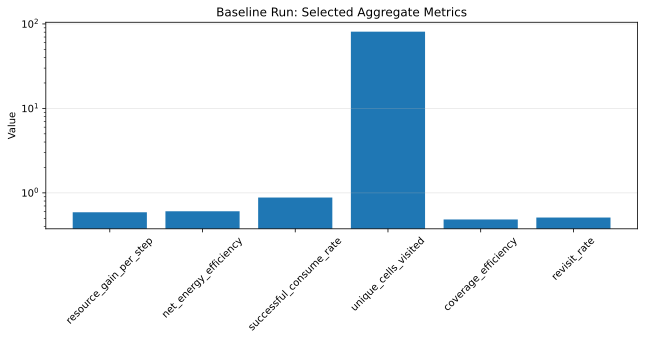

In [17]:
fig, ax = bar_plot(
    baseline_metric_snapshot['metric'],
    baseline_metric_snapshot['value'],
    title='Baseline Run: Selected Aggregate Metrics',
    ylabel='Value',
)

ax.set_yscale('log')
ax.tick_params(axis='x', rotation=45)

### What This Does Support

At this level, we can already make some legitimate statements:

- `system_aw` survives a substantial fraction of baseline episodes, but not all of them.
- The run shows non-trivial exploration: unique-cell coverage is clearly part of the behavior profile.
- Curiosity is not just present in the code; it leaves aggregate footprints such as `curiosity_dominance_rate` and `curiosity_led_move_rate`.

### What This Does Not Yet Support

From these tables alone, we still do **not** know:

- whether curiosity helped survival or hurt it in specific episodes
- how hunger and curiosity interacted within a trajectory
- whether the same aggregate profile would appear under a changed world structure

That is exactly where paired comparisons and episode traces become necessary.


## Paired Comparison: Why "What Changed?" Needs More Than Raw Run Metrics

Next we load one comparison summary from the same workspace: `world-sparse-scarcity` against the baseline anchor.

This is a good methodological example because the system stays fixed while the world changes. That isolates a central AXIS point:

> behavior is a system-world property, not a system-only property.


In [18]:
comparison_summary = scarcity_comparison['comparison_result']['summary']

run_comparison_df = pd.DataFrame(
    [
        {
            'condition': 'baseline world',
            'mean_steps': baseline_run_summary['mean_steps'],
            'death_rate': baseline_run_summary['death_rate'],
            'mean_final_vitality': baseline_run_summary['mean_final_vitality'],
            'resource_gain_per_step': mean_metric(baseline_behavior_metrics, 'resource_gain_per_step'),
            'unique_cells_visited': mean_metric(baseline_behavior_metrics, 'unique_cells_visited'),
        },
        {
            'condition': 'sparse scarcity world',
            'mean_steps': scarcity_run_summary['mean_steps'],
            'death_rate': scarcity_run_summary['death_rate'],
            'mean_final_vitality': scarcity_run_summary['mean_final_vitality'],
            'resource_gain_per_step': mean_metric(scarcity_behavior_metrics, 'resource_gain_per_step'),
            'unique_cells_visited': mean_metric(scarcity_behavior_metrics, 'unique_cells_visited'),
        },
    ]
)

comparison_summary_df = pd.DataFrame(
    [
        ('num_episodes_compared', comparison_summary['num_episodes_compared']),
        ('action_mismatch_rate_mean', comparison_summary['action_mismatch_rate']['mean']),
        ('mean_trajectory_distance', comparison_summary['mean_trajectory_distance']['mean']),
        ('mean_vitality_difference', comparison_summary['mean_vitality_difference']['mean']),
        ('final_vitality_delta_mean', comparison_summary['final_vitality_delta']['mean']),
        ('total_steps_delta_mean', comparison_summary['total_steps_delta']['mean']),
        ('reference_survival_rate', comparison_summary['reference_survival_rate']),
        ('candidate_survival_rate', comparison_summary['candidate_survival_rate']),
    ],
    columns=['comparison_metric', 'value'],
)

display(run_comparison_df)
display(comparison_summary_df)


,condition,mean_steps,death_rate,mean_final_vitality,resource_gain_per_step,unique_cells_visited
0,baseline world,182.44,0.24,0.388370,0.589241,81.04
1,sparse scarcity world,172.90,0.56,0.137932,0.442721,113.00


,comparison_metric,value
0,num_episodes_compared,50.000000
1,action_mismatch_rate_mean,0.744669
2,mean_trajectory_distance,12.464297
3,mean_vitality_difference,0.137180
4,final_vitality_delta_mean,-0.250438
5,total_steps_delta_mean,-9.540000
6,reference_survival_rate,0.760000
7,candidate_survival_rate,0.440000


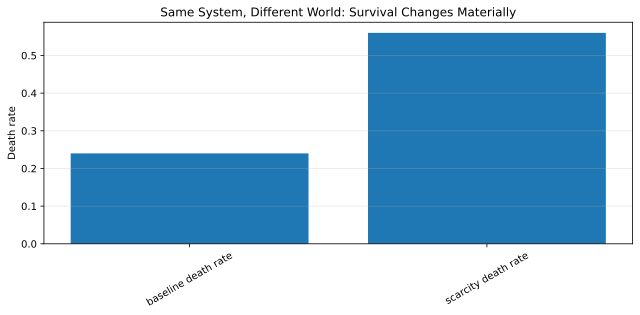

In [19]:
fig, ax = bar_plot(
    ['baseline death rate', 'scarcity death rate'],
    [baseline_run_summary['death_rate'], scarcity_run_summary['death_rate']],
    title='Same System, Different World: Survival Changes Materially',
    ylabel='Death rate',
)


### What The Comparison Adds

The paired comparison gives us something a standalone run summary cannot: a direct statement about **difference under controlled pairing**.

Here the methodological takeaway is stronger than any one scalar metric:

- action mismatch is high, so trajectories diverge substantially under the world change
- mean trajectory distance is non-trivial, so the change is spatially behavioral, not just energetic
- survival worsens sharply in the sparse scarcity world, even though the agent architecture is unchanged

This is the kind of artifact that supports claims like:

> In AXIS, changing the world structure can materially reshape the realized behavior of the same mechanistic system.

It still does **not** explain the local mechanism by itself. For that, we need a trace.


## Episode Trace Excerpt: What Mechanism-Level Evidence Looks Like

Now we move down to one persisted episode from the baseline anchor. A trace is where the AXIS-specific mechanistic story becomes inspectable.

For this notebook, the trace is not being used to prove prevalence. It is being used to show what kind of claim a trace can justify:

- what the agent observed
- which drive was active
- how arbitration weighted the drives
- which action was selected
- how vitality changed over time


In [20]:
steps = baseline_episode['steps']

step_rows = []
for step in steps:
    decision = step['system_data']['decision_data']
    observation = decision['observation']
    step_rows.append(
        {
            'timestep': step['timestep'],
            'action': step['action'],
            'vitality_before': step['vitality_before'],
            'vitality_after': step['vitality_after'],
            'resource_here': observation['current']['resource'],
            'resource_up': observation['up']['resource'],
            'resource_down': observation['down']['resource'],
            'resource_left': observation['left']['resource'],
            'resource_right': observation['right']['resource'],
            'hunger_activation': decision['hunger_drive']['activation'],
            'curiosity_activation': decision['curiosity_drive']['activation'],
            'hunger_weight': decision['arbitration']['hunger_weight'],
            'curiosity_weight': decision['arbitration']['curiosity_weight'],
        }
    )

step_df = pd.DataFrame(step_rows)
trace_excerpt = step_df[step_df['timestep'].isin([0, 20, 50, 100, 150, 180])].reset_index(drop=True)

print('Episode termination reason:', baseline_episode['termination_reason'])
print('Episode total steps:', baseline_episode['total_steps'])
print('Episode final vitality:', baseline_episode['final_vitality'])
display(trace_excerpt)


Episode termination reason: max_steps_reached
Episode total steps: 200
Episode final vitality: 0.42750000000000055


,timestep,action,vitality_before,vitality_after,resource_here,resource_up,resource_down,resource_left,resource_right,hunger_activation,curiosity_activation,hunger_weight,curiosity_weight
0,0,up,1.0000,0.9900,0.0,0.0,0.0,0.0,0.00,0.0000,1.000000,0.300000,1.000000
1,20,right,0.8000,0.7900,0.0,0.0,0.0,0.0,0.20,0.2000,0.978413,0.328000,0.640000
2,50,consume,0.5000,0.5715,0.5,0.0,0.0,0.0,0.00,0.5000,0.938148,0.475000,0.250000
3,100,down,0.5605,0.5505,1.0,0.0,1.0,0.0,1.00,0.4395,0.792332,0.435212,0.314160
4,150,left,0.5255,0.5155,0.0,0.0,0.0,0.0,0.11,0.4745,0.807976,0.457605,0.276150
5,180,up,0.6275,0.6175,0.0,0.0,0.0,0.0,0.00,0.3725,0.870506,0.397129,0.393756


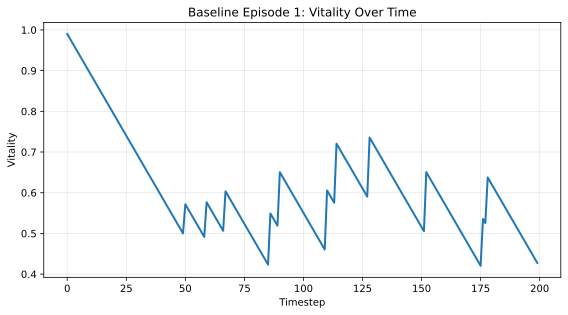

In [21]:
fig, ax = line_plot(
    step_df['timestep'],
    step_df['vitality_after'],
    title='Baseline Episode 1: Vitality Over Time',
    xlabel='Timestep',
    ylabel='Vitality',
)


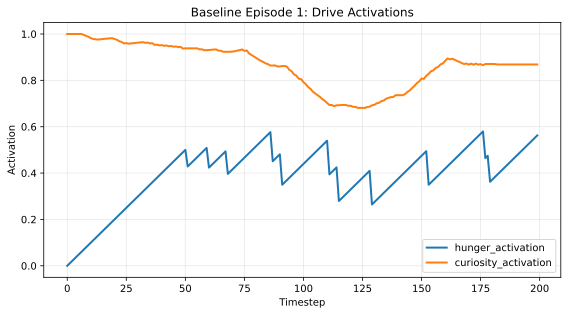

In [22]:
plt_fig, plt_ax = lines_plot(
    [
        {
            'x': step_df['timestep'],
            'y': step_df['hunger_activation'],
            'label': 'hunger_activation',
        },
        {
            'x': step_df['timestep'],
            'y': step_df['curiosity_activation'],
            'label': 'curiosity_activation',
        },
    ],
    title='Baseline Episode 1: Drive Activations',
    xlabel='Timestep',
    ylabel='Activation',
)


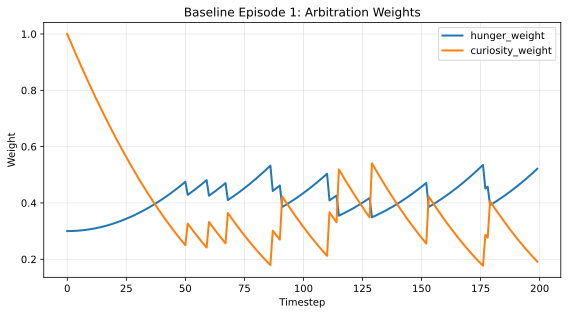

In [23]:
fig, ax = lines_plot(
    [
        {
            'x': step_df['timestep'],
            'y': step_df['hunger_weight'],
            'label': 'hunger_weight',
        },
        {
            'x': step_df['timestep'],
            'y': step_df['curiosity_weight'],
            'label': 'curiosity_weight',
        },
    ],
    title='Baseline Episode 1: Arbitration Weights',
    xlabel='Timestep',
    ylabel='Weight',
)


### What The Trace Supports

This single episode makes several AXIS-specific things visible that were invisible in the aggregate tables:

- early in the episode, curiosity is strongly active while vitality is high
- later, hunger activation rises and its arbitration weight increases
- local actions can be related back to observed resource structure and drive weighting rather than treated as opaque outputs

That is exactly why traces matter in AXIS. The system is intended to be interpretable at the level of **decision composition**, not only at the level of final scores.

### What The Trace Still Does Not Support

Even a very clean trace does not tell us by itself whether this pattern is typical. For that we need to reconnect it to aggregate evidence.

That reconnection is what the baseline behavior metrics already started to provide. For example, the run-level `curiosity_dominance_rate` and `curiosity_led_move_rate` tell us that trace-level curiosity dynamics are not just a one-off story we happened to notice in one episode.


## Claim Scoping Rules For The Rest Of The Research Series

The rest of the notebook track should use a fairly strict evidence discipline.

A good default mapping is:


In [24]:
claim_rows = [
    {
        'claim_type': 'A mechanism exists in the implementation',
        'minimum_evidence': 'Code reading + toy worked example',
        'why': 'Shows the formal rule, not its behavioral role',
    },
    {
        'claim_type': 'A mechanism can shape one concrete trajectory',
        'minimum_evidence': 'At least one persisted episode trace',
        'why': 'Shows the local causal pathway step by step',
    },
    {
        'claim_type': 'A tendency appears across many episodes',
        'minimum_evidence': 'Run summary or behavior metrics',
        'why': 'Moves from anecdote to aggregate tendency',
    },
    {
        'claim_type': 'A system or world change caused a behavioral shift',
        'minimum_evidence': 'Paired comparison plus the relevant run summaries',
        'why': 'Localizes change under controlled variation',
    },
    {
        'claim_type': 'An interpretation is robust enough to build on later',
        'minimum_evidence': 'Mechanism explanation + trace + aggregate pattern + comparison',
        'why': 'Combines interpretability, prevalence, and counterfactual difference',
    },
]

claim_df = pd.DataFrame(claim_rows)
display(claim_df)


,claim_type,minimum_evidence,why
0,A mechanism exists in the implementation,Code reading + toy worked example,"Shows the formal rule, not its behavioral role"
1,A mechanism can shape one concrete trajectory,At least one persisted episode trace,Shows the local causal pathway step by step
2,A tendency appears across many episodes,Run summary or behavior metrics,Moves from anecdote to aggregate tendency
3,A system or world change caused a behavioral s...,Paired comparison plus the relevant run summaries,Localizes change under controlled variation
4,An interpretation is robust enough to build on...,Mechanism explanation + trace + aggregate patt...,"Combines interpretability, prevalence, and cou..."


## Closing Perspective

The central methodological point is simple, but it is easy to lose once later notebooks become more detailed:

> AXIS results become meaningful only when mechanistic explanation, traces, metrics, and comparisons are interpreted together.

If later notebooks make claims about hunger, curiosity, arbitration, prediction, or world structure, they should not quietly lean on only one layer of evidence when the claim actually needs several.

That is the standard this notebook is meant to set for the rest of the research layer.
